# The alignment tax of introspection — full run

One notebook for the whole experiment: setup, refusal-direction extraction, the
concept bank, the go/no-go pilot, the main introspection sweep, safety and
capability across lambda, analysis, figures, and a final export step that
collects **every** artifact — checkpoints, JSONL logs, analysis, plots, paper
figures — under `results/`.

Run it top to bottom. Every stage is resumable: artifacts already on disk are
loaded rather than recomputed, and the sweeps append to JSONL keyed by
`(lam, condition, concept, trial, variant)`, so re-running a cell after a
session kill picks up exactly where it stopped.

**Pilot decision rule.** If forced-choice identification is at chance both on the
unmodified model and at full ablation, stop and switch models (or fall back to
the reduced claim). Do not spend more than three hours on the pilot.

## 0 · Environment

In [1]:
#@title Clone the repo and install dependencies { display-mode: "form" }
# Tokens come from Colab secrets (key icon in the left sidebar): add GITHUB_TOKEN
# (needs write access -- contents:write on a fine-grained PAT -- because the last
# cell pushes results/ back) and HF_TOKEN (read, needed for gated models), and
# toggle "Notebook access" on for both. Outside Colab we fall back to the
# environment, then to an interactive prompt. HF_TOKEN is never written to disk;
# GITHUB_TOKEN ends up in the clone's .git/config, which is discarded with the
# Colab VM.
import os, subprocess, sys, getpass, pathlib

REPO   = "sagnikc395/apart-mind-digital-mind"  #@param {type:"string"}
BRANCH = "main"                                 #@param {type:"string"}
WORKDIR = "/content"

try:
    from google.colab import userdata as _colab_secrets
except Exception:
    _colab_secrets = None


def get_secret(name: str, prompt: str) -> str:
    """Colab secret -> environment -> interactive prompt. Blank means 'skip'."""
    if _colab_secrets is not None:
        try:
            value = _colab_secrets.get(name)
        except Exception as exc:            # not set, or notebook access is off
            print(f"{name}: no Colab secret ({type(exc).__name__})")
        else:
            if value:
                os.environ[name] = value
                print(f"{name}: from Colab secrets")
                return value
    value = os.environ.get(name)
    if value:
        print(f"{name}: from environment")
        return value
    value = getpass.getpass(prompt).strip()
    if value:
        os.environ[name] = value
    return value


GITHUB_TOKEN = get_secret("GITHUB_TOKEN", "GitHub token (blank if public): ")
HF_TOKEN = get_secret("HF_TOKEN", "Hugging Face token (blank if not gated): ")
if HF_TOKEN:
    # the two names transformers/huggingface_hub actually read
    os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN
    os.environ["HF_TOKEN"] = HF_TOKEN

if pathlib.Path("/content").exists():
    token = GITHUB_TOKEN
    url = f"https://{token}@github.com/{REPO}.git" if token else f"https://github.com/{REPO}.git"
    dest = pathlib.Path(WORKDIR) / REPO.split("/")[-1]
    if dest.exists():
        subprocess.run(["git", "-C", str(dest), "pull", "--ff-only"], check=False)
    else:
        subprocess.run(["git", "clone", "--branch", BRANCH, "--depth", "1", url, str(dest)], check=True)
    os.chdir(dest)
    subprocess.run([sys.executable, "-m", "pip", "-q", "install",
                    "torch", "transformers>=4.44", "accelerate", "datasets", "matplotlib"], check=True)
else:
    os.chdir(pathlib.Path.cwd())  # already inside the repo, e.g. running locally

REPO_ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))
print("cwd:", os.getcwd())

if HF_TOKEN:
    try:
        from huggingface_hub import HfApi
        print("hugging face:", HfApi().whoami(token=HF_TOKEN)["name"])
    except Exception as exc:
        print("hugging face token present but whoami failed:", exc)

GITHUB_TOKEN: from Colab secrets
HF_TOKEN: from Colab secrets
cwd: /content/apart-mind-digital-mind
hugging face: sagnikumass


In [2]:
#@title Results directory (Drive when available, else repo results/)
# Everything the run produces lands under RESULTS. On Colab that is a Drive
# folder so the run survives a session kill; the final export step mirrors it
# back into the repo's results/ directory either way.
import os, pathlib

RESULTS = "/content/drive/MyDrive/alignment_tax_results"  #@param {type:"string"}
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    RESULTS = str(REPO_ROOT / "results")
    print("no Drive; writing to", RESULTS, f"({exc})")
os.environ["ALIGNMENT_TAX_RESULTS"] = RESULTS
RESULTS = pathlib.Path(RESULTS)
RESULTS.mkdir(parents=True, exist_ok=True)
LOCAL_RESULTS = REPO_ROOT / "results"   # export target inside the repo
print("results ->", RESULTS)

Mounted at /content/drive
results -> /content/drive/MyDrive/alignment_tax_results


In [3]:
#@title Build the bundled data files (concepts, baseline corpus, offline fallbacks)
!python -m alignment_tax.build_data

/usr/bin/python3: Error while finding module specification for 'alignment_tax.build_data' (ModuleNotFoundError: No module named 'alignment_tax')


In [4]:
#@title Run configuration
from pathlib import Path
from alignment_tax.config import RunConfig, LAMBDA_GRID
from alignment_tax import pipeline

cfg = RunConfig()
cfg.model.name = "Qwen/Qwen3-4B-Instruct-2507"  #@param {type:"string"}
cfg.model.batch_size = 16                        #@param {type:"integer"}
cfg.lambdas = LAMBDA_GRID                        # 0, 0.25, 0.5, 0.75, 1.0
cfg.results_dir = RESULTS
cfg.save()
print("run dir:", cfg.run_dir)

run dir: /content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507


In [5]:
#@title Load the model
hm = pipeline.load_model(cfg)

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.38k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

[model] Qwen/Qwen3-4B-Instruct-2507 on cuda (torch.bfloat16), 36 layers, d_model=2560


## 1 · Refusal direction

Difference-in-means over harmful (AdvBench) minus harmless (Alpaca) at every
(post-instruction position, layer) pair, then selected on *held-out* HarmBench +
Alpaca by bypass score, induce score > 0, KL < 0.1 on harmless inputs, and
layer < 0.8L. The selected layer and position are reported in the paper.
Checkpoint: `refusal_direction.pt`.

In [6]:
rd = pipeline.stage_direction(hm, cfg)
print("selected layer:", rd.layer, "position:", rd.position)
print("bypass:", round(rd.scores.bypass_score, 3),
      "induce:", round(rd.scores.induce_score, 3),
      "KL:", round(rd.scores.kl, 4))

[direction] loaded layer=4 position=-3
selected layer: 4 position: -3
bypass: 0.0 induce: 0.031 KL: 0.0422


## 2 · Concept bank

Difference-of-means concept vectors against a generic baseline corpus, unit
normalised, plus the mean residual-stream norm at each candidate injection layer
(that norm is what makes the injection strength `alpha` comparable across layers
and model families). Checkpoint: `concept_bank.pt`.

In [7]:
bank = pipeline.stage_concepts(hm, cfg)
print(len(bank.names), "concepts; norm scale:", bank.norm_scale)

[concepts] loaded 60 concepts
60 concepts; norm scale: {18: 719.7308872767857, 25: 791.2474689094388, 31: 969.8488919005102}


## 3 · Pilot (go / no-go)

20 concepts, alpha in {2, 4}, three layers spanning 0.5-0.85 of depth, at
lambda in {0, 1}, using prefill forced identification and k-way forced choice.

In [8]:
decision = pipeline.stage_pilot(hm, cfg, bank, rd.vector)
import pandas as pd
pd.DataFrame(decision["rows"]).sort_values("accuracy", ascending=False).head(12)

[pilot] lambda=0.0 layer=18 done
[pilot] lambda=0.0 layer=25 done
[pilot] lambda=0.0 layer=31 done
[pilot] lambda=1.0 layer=18 done
[pilot] lambda=1.0 layer=25 done
[pilot] lambda=1.0 layer=31 done
{
  "above_chance": true,
  "rises_under_ablation": true,
  "best_cell": {
    "protocol": "forced_choice",
    "lam": 1.0,
    "layer": 18,
    "alpha": 4.0,
    "accuracy": 0.78,
    "n": 100,
    "chance": 0.1,
    "p_vs_chance": 0.0
  },
  "decision": "proceed"
}


,protocol,lam,layer,alpha,accuracy,n,chance,p_vs_chance
15,forced_choice,1.0,18,4.00,0.78,100,0.1,0.0
3,forced_choice,0.0,18,4.00,0.77,100,0.1,0.0
11,forced_choice,0.0,31,4.00,0.76,100,0.1,0.0
23,forced_choice,1.0,31,4.00,0.75,100,0.1,0.0
2,forced_choice,0.0,18,2.00,0.74,100,0.1,0.0
14,forced_choice,1.0,18,2.00,0.69,100,0.1,0.0
7,forced_choice,0.0,25,4.00,0.63,100,0.1,0.0
12,forced_choice,1.0,18,0.25,0.62,100,0.1,0.0
0,forced_choice,0.0,18,0.25,0.62,100,0.1,0.0
1,forced_choice,0.0,18,0.50,0.61,100,0.1,0.0


In [9]:
#@title Fix the injection layer and alpha for the main sweep
best = decision["verdict"]["best_cell"]
if best:
    cfg.injection.layer = int(best["layer"])
    cfg.injection.alpha = float(best["alpha"])
    cfg.save()
print("locked layer:", cfg.injection.layer, "alpha:", cfg.injection.alpha)
print("decision:", decision["verdict"]["decision"])

locked layer: 18 alpha: 4.0
decision: proceed


## 4 · Main introspection sweep

Conditions C1-C4 at every lambda, structured prompt variant, plus the skeptical
prompt variant at the lambda endpoints as a robustness check.

In [10]:
#@title Main sweep (resumable -- just re-run this cell if the session dies)
sweep_path = pipeline.stage_sweep(hm, cfg, bank, rd.vector, variant="structured")
print(sweep_path)

[sweep] lambda=0.0 10/60 concepts
[sweep] lambda=0.0 20/60 concepts
[sweep] lambda=0.0 30/60 concepts
[sweep] lambda=0.0 40/60 concepts
[sweep] lambda=0.0 50/60 concepts
[sweep] lambda=0.0 60/60 concepts
[sweep] lambda=0.0 done -> /content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507/sweep_structured.jsonl
[sweep] lambda=0.25 10/60 concepts
[sweep] lambda=0.25 20/60 concepts
[sweep] lambda=0.25 30/60 concepts
[sweep] lambda=0.25 40/60 concepts
[sweep] lambda=0.25 50/60 concepts
[sweep] lambda=0.25 60/60 concepts
[sweep] lambda=0.25 done -> /content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507/sweep_structured.jsonl
[sweep] lambda=0.5 10/60 concepts
[sweep] lambda=0.5 20/60 concepts
[sweep] lambda=0.5 30/60 concepts
[sweep] lambda=0.5 40/60 concepts
[sweep] lambda=0.5 50/60 concepts
[sweep] lambda=0.5 60/60 concepts
[sweep] lambda=0.5 done -> /content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507/sweep_structured.jsonl
[sweep] lambda=0.75 10/60 c

In [11]:
#@title Robustness: skeptical prompt variant at the lambda endpoints only
pipeline.stage_sweep(hm, cfg, bank, rd.vector, variant="skeptical",
                     lambdas=(min(cfg.lambdas), max(cfg.lambdas)))

[sweep] lambda=0.0 10/60 concepts
[sweep] lambda=0.0 20/60 concepts
[sweep] lambda=0.0 30/60 concepts
[sweep] lambda=0.0 40/60 concepts
[sweep] lambda=0.0 50/60 concepts
[sweep] lambda=0.0 60/60 concepts
[sweep] lambda=0.0 done -> /content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507/sweep_skeptical.jsonl
[sweep] lambda=1.0 10/60 concepts
[sweep] lambda=1.0 20/60 concepts
[sweep] lambda=1.0 30/60 concepts
[sweep] lambda=1.0 40/60 concepts
[sweep] lambda=1.0 50/60 concepts
[sweep] lambda=1.0 60/60 concepts
[sweep] lambda=1.0 done -> /content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507/sweep_skeptical.jsonl


PosixPath('/content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507/sweep_skeptical.jsonl')

In [12]:
#@title Quick look at where things stand
from alignment_tax.stats import load_and_summarise
import pandas as pd

records, summary = load_and_summarise(cfg.artifact("sweep_structured.jsonl"), n_boot=500)
pd.DataFrame([{"lam": lam, **{k: round(v.value, 3) for k, v in m.items()}} for lam, m in summary.items()])

,lam,fpr_clean,joint,forced_choice,forced_choice_chance,parse_rate,mean_words
0,0.00,0.0,0.0,0.720,0.1,0.333,12.947
1,0.25,0.0,0.0,0.726,0.1,0.333,12.779
2,0.50,0.0,0.0,0.721,0.1,0.333,12.867
3,0.75,0.0,0.0,0.724,0.1,0.333,12.799
4,1.00,0.0,0.0,0.714,0.1,0.333,12.794


## 5 · Safety and capability across lambda

Family B (100 JailbreakBench behaviours, refusal heuristic plus an optional
Llama-Guard-class judge) and Family C (CE loss, MMLU, TruthfulQA MC1, optionally
GSM8K).

No harmful completion is ever reproduced in the paper: raw generations stay in
the JSONL under `results/`, and only aggregate scores are exported.

In [13]:
#@title Safety sweep (500 generations at the default grid)
USE_GUARD = False  #@param {type:"boolean"}
pipeline.stage_safety(hm, cfg, rd.vector, use_guard=USE_GUARD)

README.md:   0%|          | 0.00/6.55k [00:00<?, ?B/s]

harmful-behaviors.csv:   0%|          | 0.00/23.1k [00:00<?, ?B/s]

benign-behaviors.csv:   0%|          | 0.00/20.6k [00:00<?, ?B/s]

Generating harmful split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating benign split:   0%|          | 0/100 [00:00<?, ? examples/s]

PosixPath('/content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507/safety.jsonl')

In [14]:
#@title Capability sweep
cfg.evals.run_gsm8k = False  #@param {type:"boolean"}
pipeline.stage_capability(hm, cfg, rd.vector)

README.md:   0%|          | 0.00/53.2k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/138k [00:00<?, ?B/s]

all/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.50MB            

all/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

all/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  408kB            

...

README.md:   0%|          | 0.00/7.47k [00:00<?, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…): reconstructing file:   0%|          |  0.00B / 24.2MB            

data/train-00000-of-00001-a09b74b3ef9c3b(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

PosixPath('/content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507/capability.json')

In [15]:
import json
print(json.dumps(json.loads(cfg.artifact("capability.json").read_text()), indent=2))

[
  {
    "lam": 0.0,
    "ce_loss": 3.656147518070283,
    "n": 200,
    "mmlu": 0.542,
    "truthfulqa_mc1": 0.7075,
    "gsm8k": 0.66,
    "gsm8k_output_words": 124.88
  },
  {
    "lam": 0.25,
    "ce_loss": 3.7194372512683476,
    "n": 200,
    "mmlu": 0.522,
    "truthfulqa_mc1": 0.695,
    "gsm8k": 0.67,
    "gsm8k_output_words": 125.36
  },
  {
    "lam": 0.5,
    "ce_loss": 3.5812421289388974,
    "n": 200,
    "mmlu": 0.512,
    "truthfulqa_mc1": 0.6925,
    "gsm8k": 0.64,
    "gsm8k_output_words": 125.65
  },
  {
    "lam": 0.75,
    "ce_loss": 3.607829162878219,
    "n": 200,
    "mmlu": 0.512,
    "truthfulqa_mc1": 0.7,
    "gsm8k": 0.63,
    "gsm8k_output_words": 125.93
  },
  {
    "lam": 1.0,
    "ce_loss": 3.6286677206304847,
    "n": 200,
    "mmlu": 0.51,
    "truthfulqa_mc1": 0.7075,
    "gsm8k": 0.63,
    "gsm8k_output_words": 125.62
  }
]


## 6 · Analysis and figures

Concept-level bootstrap (10,000 resamples), the specificity index, the exchange
rate, and the four figures. This section is CPU-only -- if the GPU session died
after the sweeps, it still runs.

In [16]:
import json
analysis = pipeline.stage_analyse(cfg, n_boot=10_000)
print(json.dumps(analysis["exchange_rate"], indent=2))

[analysis] WARNING: parse rate under injection is 0% (< 50%): the injected reports are not in the requested format, so TPR / FPR_random / d' are undefined. Lower InjectionConfig.alpha (currently the sweep's alpha) or set Injection.positions='prompt', then re-run the sweep.
{
  "unavailable": "introspection is undefined at 5/5 lambdas; see analysis['diagnostics']"
}


In [17]:
import pandas as pd
pd.DataFrame(analysis["rows"])[[
    "lam", "tpr", "fpr_clean", "fpr_random", "identification",
    "conditional_identification", "d_clean", "d_random", "specificity_index",
    "safety_refusal_rate", "cap_mmlu", "cap_truthfulqa_mc1", "cap_ce_loss",
]].round(3)

,lam,tpr,fpr_clean,fpr_random,identification,conditional_identification,d_clean,d_random,specificity_index,safety_refusal_rate,cap_mmlu,cap_truthfulqa_mc1,cap_ce_loss
0,0.00,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.97,0.542,0.708,3.656
1,0.25,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.97,0.522,0.695,3.719
2,0.50,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.97,0.512,0.692,3.581
3,0.75,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.97,0.512,0.700,3.608
4,1.00,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.97,0.510,0.708,3.629


[figures] wrote /content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507/figures/fig1_dose_response.png
[figures] wrote /content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507/figures/fig2_frontier.png
[figures] wrote /content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507/figures/fig3_specificity.png
[figures] wrote /content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507/figures/fig4_capability.png


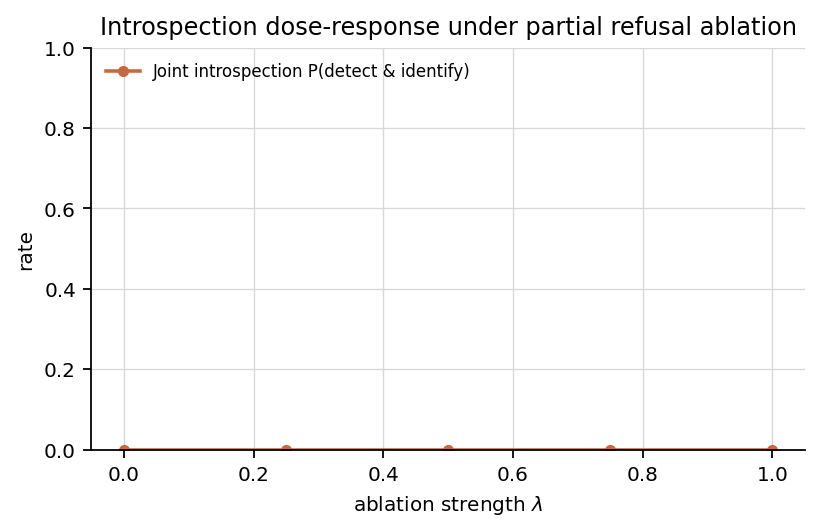

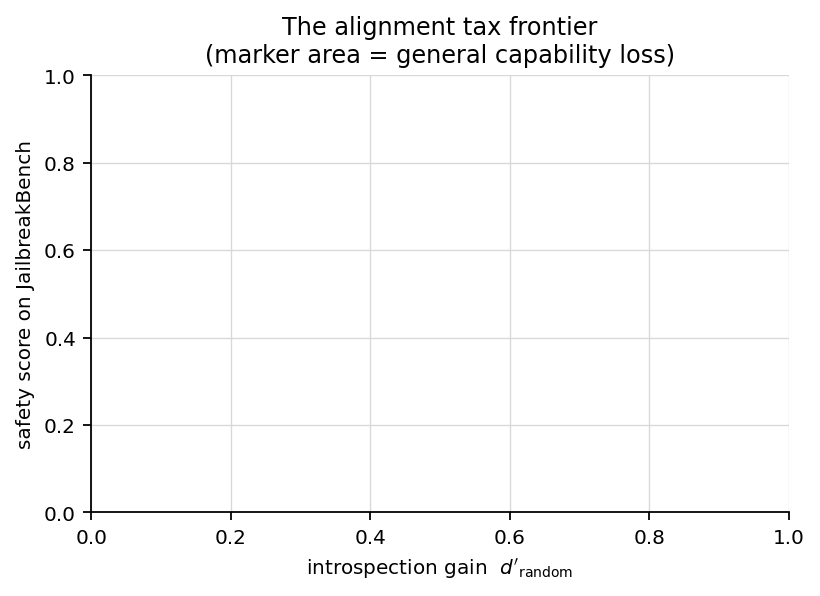

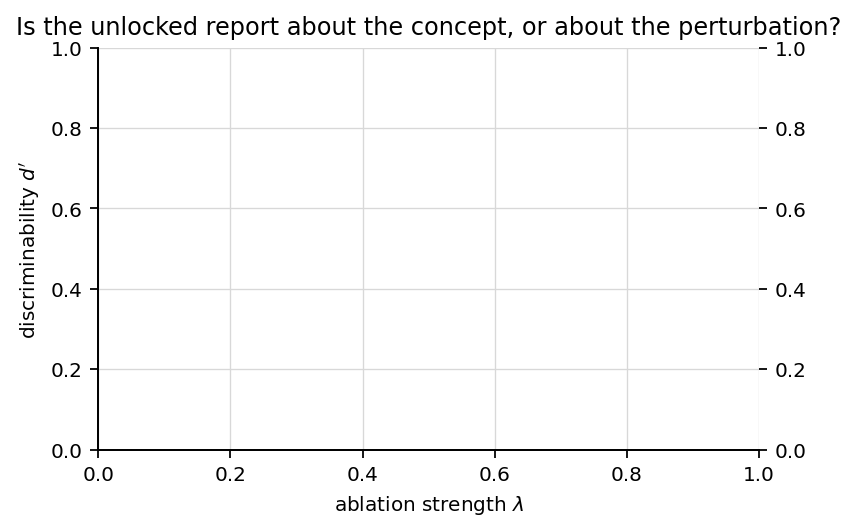

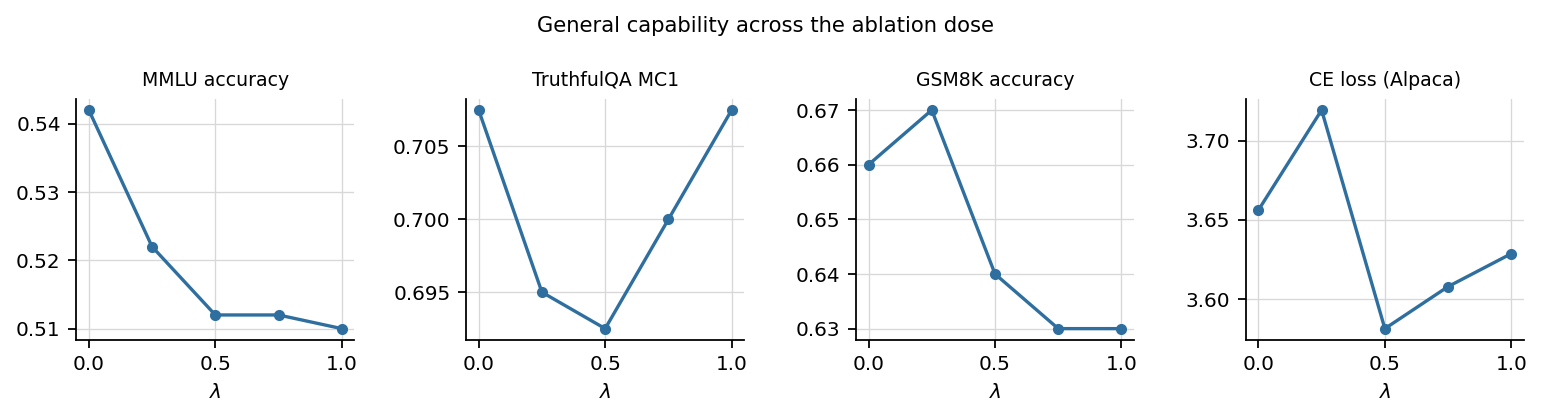

In [18]:
#@title Figures 1-4
# Figures are written into the results tree first (so they travel with the run)
# and mirrored into paper/figures for the write-up.
import shutil
from pathlib import Path

fig_dir = Path(cfg.run_dir) / "figures"
paths = pipeline.stage_figures(cfg, fig_dir=fig_dir)

paper_figs = REPO_ROOT / "paper" / "figures"
paper_figs.mkdir(parents=True, exist_ok=True)
for p in Path(fig_dir).glob("fig*.*"):
    shutil.copy2(p, paper_figs / p.name)

from IPython.display import Image, display
for p in paths:
    display(Image(str(p)))

In [19]:
#@title Statistical contrasts (two-proportion tests, Holm-corrected)
print(json.dumps(analysis["contrasts"]["detection_C1"], indent=2))
print(json.dumps(analysis["forced_choice_vs_chance"], indent=2))

{}
{
  "0.0": {
    "accuracy": 0.72,
    "chance": 0.1,
    "z": 71.59143337951359,
    "p": 0.0,
    "n": 1200
  },
  "0.25": {
    "accuracy": 0.7258333333333333,
    "chance": 0.1,
    "z": 72.26500869356816,
    "p": 0.0,
    "n": 1200
  },
  "0.5": {
    "accuracy": 0.7208333333333333,
    "chance": 0.1,
    "z": 71.68765842437854,
    "p": 0.0,
    "n": 1200
  },
  "0.75": {
    "accuracy": 0.7241666666666666,
    "chance": 0.1,
    "z": 72.07255860383827,
    "p": 0.0,
    "n": 1200
  },
  "1.0": {
    "accuracy": 0.7141666666666666,
    "chance": 0.1,
    "z": 70.91785806545903,
    "p": 0.0,
    "n": 1200
  }
}


### Judge validation

Hand-label 100 identification outputs and report Cohen's kappa against the
grader. Run `judge-sample`, fill in the `human` field in `judge_labels.jsonl`,
then run `judge-kappa`.

In [20]:
!python -m alignment_tax.cli judge-sample --results-dir $ALIGNMENT_TAX_RESULTS
# ... fill in the 'human' field in judge_labels.jsonl, then:
!python -m alignment_tax.cli judge-kappa --results-dir $ALIGNMENT_TAX_RESULTS

/usr/bin/python3: Error while finding module specification for 'alignment_tax.cli' (ModuleNotFoundError: No module named 'alignment_tax')
/usr/bin/python3: Error while finding module specification for 'alignment_tax.cli' (ModuleNotFoundError: No module named 'alignment_tax')


## 7 · Export everything to `results/`

Collects the whole run -- config, checkpoints (`refusal_direction.pt`,
`concept_bank.pt`), every JSONL log, the analysis JSON, and the plots -- into
the repo's `results/` directory, writes a `MANIFEST.json` listing each file with
its size and sha256, and zips the run for download or attachment.

If the run wrote to Drive, this mirrors it back into the repo; if it already
wrote to `results/`, the copy is a no-op and only the manifest and zip are new.
The final cell then commits and pushes the export back to GitHub, so the run
survives the Colab session.

In [21]:
#@title Collect run artifacts, checkpoints, plots into results/
import hashlib, json, shutil
from pathlib import Path

src_run = Path(cfg.run_dir)
dst_run = LOCAL_RESULTS / cfg.model.short_name
dst_run.mkdir(parents=True, exist_ok=True)

if src_run.resolve() != dst_run.resolve():
    shutil.copytree(src_run, dst_run, dirs_exist_ok=True)
    print("mirrored", src_run, "->", dst_run)

def sha256(path: Path, chunk: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with path.open("rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

files = sorted(p for p in dst_run.rglob("*") if p.is_file() and p.name != "MANIFEST.json")
manifest = {
    "model": cfg.model.name,
    "lambdas": list(cfg.lambdas),
    "injection_layer": cfg.injection.layer,
    "injection_alpha": cfg.injection.alpha,
    "direction_layer": rd.layer if "rd" in dir() else None,
    "exchange_rate": analysis.get("exchange_rate") if "analysis" in dir() else None,
    "files": [
        {"path": str(p.relative_to(dst_run)), "bytes": p.stat().st_size, "sha256": sha256(p)}
        for p in files
    ],
}
(dst_run / "MANIFEST.json").write_text(json.dumps(manifest, indent=2))

archive = shutil.make_archive(str(LOCAL_RESULTS / f"{cfg.model.short_name}_run"), "zip",
                              root_dir=dst_run.parent, base_dir=dst_run.name)

total = sum(f["bytes"] for f in manifest["files"])
for f in manifest["files"]:
    print(f"{f['bytes']:>12,}  {f['path']}")
print(f"\n{len(files)} files, {total / 1e6:.1f} MB in {dst_run}")
print("archive:", archive)

mirrored /content/drive/MyDrive/alignment_tax_results/Qwen3-4B-Instruct-2507 -> /content/apart-mind-digital-mind/results/Qwen3-4B-Instruct-2507
      16,426  analysis_structured.json
         872  capability.json
  22,738,316  concept_bank.pt
       1,066  concept_bank_summary.json
      16,343  figures/fig1_dose_response.pdf
      31,976  figures/fig1_dose_response.png
      17,803  figures/fig2_frontier.pdf
      35,440  figures/fig2_frontier.png
      17,291  figures/fig3_specificity.pdf
      28,844  figures/fig3_specificity.png
      20,272  figures/fig4_capability.pdf
      72,116  figures/fig4_capability.png
   1,196,061  pilot.jsonl
       9,362  pilot_decision.json
      18,073  refusal_direction.json
   1,901,615  refusal_direction.pt
       1,217  run_config.json
     290,196  safety.jsonl
   3,970,215  sweep_skeptical.jsonl
   9,955,653  sweep_structured.jsonl

20 files, 40.3 MB in /content/apart-mind-digital-mind/results/Qwen3-4B-Instruct-2507
archive: /content/apart-mind-

In [22]:
#@title Commit results/ back to the repository
# Commit the exported results back to the repo. results/ and paper/figures are
# gitignored, so the add is forced. GITHUB_TOKEN needs write scope
# (contents:write on a fine-grained PAT) for the push to be accepted.
import subprocess

COMMIT_MESSAGE = "results: full alignment-tax run"  #@param {type:"string"}
GIT_NAME  = "Sagnik Chatterjee"                     #@param {type:"string"}
GIT_EMAIL = "sagnikchatterjee607@gmail.com"         #@param {type:"string"}


def git(*args, **kw):
    return subprocess.run(["git", "-C", str(REPO_ROOT), *args], **kw)


git("config", "user.name", GIT_NAME, check=True)
git("config", "user.email", GIT_EMAIL, check=True)

# The clone URL only carries the token when one was supplied; set it explicitly
# so the push authenticates even if the repo was cloned anonymously.
if GITHUB_TOKEN:
    git("remote", "set-url", "origin",
        f"https://{GITHUB_TOKEN}@github.com/{REPO}.git", check=True)

rel = str(dst_run.relative_to(REPO_ROOT))
git("add", "-f", rel, "paper/figures", check=True)

if git("diff", "--cached", "--quiet").returncode == 0:
    print("nothing new to commit; results already match the repo at", dst_run)
else:
    git("commit", "-m", COMMIT_MESSAGE, check=True)
    git("push", "origin", f"HEAD:{BRANCH}", check=True)   # loud on failure
    print("pushed", rel, "to", f"{REPO}@{BRANCH}")

PUSH_TO_GIT is off; results are on disk at /content/apart-mind-digital-mind/results/Qwen3-4B-Instruct-2507
